In [16]:
include("main.jl")
using .KronMatrixModule

In [3]:
A = rand(5,4)
B = rand(7,9)
K = KronMatrix2(A, B)
K_32 = KronMatrix2(Float32, A, B) # implicit change 
K_16 = Float16.(K) # explicit change 

display("Type of K is $(typeof(K))")
display("Type of K_32 is $(typeof(K_32))")
display("Type of K_16 is $(typeof(K_16))")


"Type of K is KronMatrix2{Float64}"

"Type of K_32 is KronMatrix2{Float32}"

"Type of K_16 is KronMatrix2{Float16}"

In [4]:
using LinearAlgebra
K2 = kron(A, B)
display("Float64: $(norm(K2 - full(K)))")

### 

# Precision check 
display("Float16: $(norm(K2 - full((K_16))))")
display("Type of full K_16 is $(typeof(full(K_16)))")

"Float64: 0.0"

"Float16: 0.003509052172209988"

"Type of full K_16 is Matrix{Float16}"

In [5]:
print("Float64 multiplication norm: ")

# multiplication 
x = rand(size(K,2),1)
b = K*x
display(norm(b - K2*x))

# multiple columns
x_m = rand(size(K,2),10);
b = K*x_m;
display(norm(b - K2*x_m))

# multiplty on the left 
y = rand(10,size(K,1))
z = y*K
display(norm(z - y*K2))

### 

print("\n")

# Precision check 
print("Float16 norm: ")
x = convert(Matrix{Float16}, x)
b = K_16*x
display(norm(b - K2*x))
display("Type of z is $(typeof(b))")

# multiple columns
x_m = convert(Matrix{Float16}, x_m)
b = K_16*x_m;
display(norm(b - K2*x_m))
display("Type of z is $(typeof(b))")

# multiplty on the left 
y = convert(Matrix{Float16}, y)
z = y*K_16
display(norm(z - y*K2))
display("Type of z is $(typeof(z))")

Float64 multiplication norm: 

4.457514335395259e-15

1.4790570975425586e-14

1.5217752116818806e-14


Float16 norm: 

...

"Type of z is Matrix{Float16}"

0.029682834368765187

"Type of z is Matrix{Float16}"

0.030778761853106844

"Type of z is Transpose{Float16, Matrix{Float16}}"

In [6]:
# division 
A = rand(4,4) 
B = rand(7,7)
K = KronMatrix2(A, B)
K2 = kron(A, B)
b = rand(size(K,1), 1)
x = K\b
display("Float64: $(norm(x - K2\b)/norm(x))")

### 

# Precision check 
K_16 = KronMatrix2(Float16, A, B)
b = convert(Matrix{Float16}, b)
x = K_16\b
display("Float16: $(norm(x - K2\b)/norm(x))")
display("Type of x is $(typeof(x))")

"Float64: 1.8551287759205215e-15"

"Float16: 0.001369409031617475"

"Type of x is Vector{Float16}"

In [7]:
# transpose 
display("Float64: $(norm(full(K') - K2'))")

### 

# Precision check 
display("Float16: $(norm(full(K_16') - K2'))")

"Float64: 0.0"

"Float16: 0.0030094977599589307"

In [8]:
# svd
U, S, V = svd(K)
print("Float64 types: ")
display(typeof(U))
display(typeof(S))
display(typeof(V))

### 

# Precision check 
U, S, V = svd(K_16)
print("Float16 types: ")
display(typeof(U))
display(typeof(S))
display(typeof(V))

Float64 types: 

KronMatrix2{Float64}

KronMatrix2{Float64}

KronMatrix2{Float64}

Float16 types: 

KronMatrix2{Float16}

KronMatrix2{Float16}

KronMatrix2{Float16}

In [9]:
# lu
L, U = lu(K)
print("Float64 types: ")
display(typeof(L))
display(typeof(U))

### 

# Precision check 
L, U = lu(K_16)
print("Float16 types: ")
display(typeof(L))
display(typeof(U))

Float64 types: 

KronMatrix2{Float64}

KronMatrix2{Float64}

Float16 types: 

KronMatrix2{Float16}

KronMatrix2{Float16}

In [ ]:
# AugMatVecMult 
A = rand(5, 5)
B = rand(5, 5)
K = KronMatrix2(A, B)
b = rand(50)
lambda = 0.06

z = AugMatVecMult(K, lambda, b) # check function 

K_exp = kron(A, B) # explicit form
K_exp_reg = [
    I(size(K_exp, 1))        K_exp;
    transpose(K_exp)   -lambda^2 * I(size(K_exp, 2))
]

z_exp = K_exp_reg * b # explicit muti

norm(z - z_exp) # check for difference

3.1264164235997252e-15

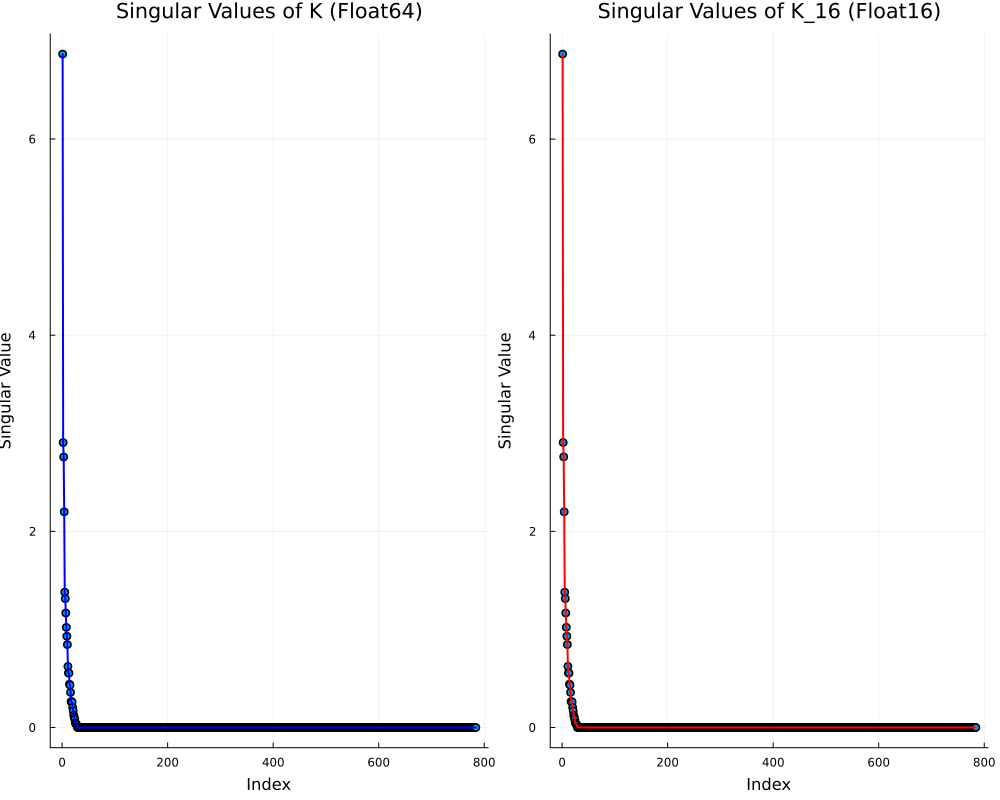

In [12]:
using Plots

# First SVD
s1 = svd(K; full=false)
p1 = plot(s1;
    seriestype = :scatter,
    line = (:solid, 2, :blue),
    xlabel = "Index",
    ylabel = "Singular Value",
    title = "Singular Values of K (Float64)",
    legend = false,
    fontsize = 18)
plot!(p1, s1, line = (:solid, 2, :blue))  # Optional line overlay

# Second SVD
s2 = svd(K_16; full=false)
p2 = plot(s2;
    seriestype = :scatter,
    line = (:solid, 2, :red),
    xlabel = "Index",
    ylabel = "Singular Value",
    title = "Singular Values of K_16 (Float16)",
    legend = false,
    fontsize = 18)
plot!(p2, s2, line = (:solid, 2, :red))  # Optional line overlay

# Combine 
plot(p1, p2, layout = (1, 2), size=(1000, 800))

# the largest singular values of Float16 are slightly bigger than that of Float64. 